# At what age do athletes reach peak performance, and does this differ by event and gender?

This project looks at the relationship between **age and performance in elite athletics**.

I have selected four events:

- 100 metres
- Marathon
- Long Jump
- Shot Put

Men and women are analysed separately because performance patterns may differ by event and gender.

The analysis starts with data cleaning and exploratory data analysis (EDA). I then use **linear regression** to investigate whether there is a simple linear relationship between age and performance. After this, I use **second-degree polynomial regression** to investigate whether the relationship is curved and whether the model can estimate a valid peak-performance age.

The aim is not to assume that age explains athletic performance on its own. The model results are used to understand how much of the variation in performance can be explained by age and where the limitations are.

## My approach

The code in this notebook is written in a clear, step-by-step style. I have used named variables, simple loops and comments so that each stage of the analysis can be followed easily.

The main focus is on showing the data science process and explaining why each step is being carried out, rather than making the Python code as short or complex as possible.

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

In [106]:
# Load the athletics dataset into a Pandas DataFrame
df = pd.read_csv("datasets/world-athletics_all-time-top-lists.csv")

In [107]:
# Preview the first five rows of the dataset
df.head()

,all_time_rank,results_score,event,category,event_rank,mark,competitor,nat,date_of_birth,pos,...,venue,age,wind,mark_details,year_of_birth,event_name,event_type,environment,age_category,gender
0,1.0,1382.0,Women's Discus Throw,Outdoor Senior - Women,1,76.8,Gabriele REINSCH,GDR,1963-09-23,1.0,...,Neubrandenburg (GDR),24.8,NaN,NaN,1963.0,discus-throw,throws,outdoor,senior,women
1,2.0,1372.0,Women's Shot Put,Outdoor Senior - Women,1,22.63,Natalya LISOVSKAYA,URS,1962-07-16,1.0,...,Moskva (URS),24.9,NaN,NaN,1962.0,shot-put,throws,outdoor,senior,women
2,3.0,1371.0,Women's Shot Put,Outdoor Senior - Women,2,22.6,Natalya LISOVSKAYA,URS,1962-07-16,NaN,...,Moskva (URS),24.9,NaN,NaN,1962.0,shot-put,throws,outdoor,senior,women
3,4.0,1367.0,Women's Shot Put,Outdoor Senior - Women,3,22.55,Natalya LISOVSKAYA,URS,1962-07-16,1.0,...,Tallinn (EST),26.0,NaN,NaN,1962.0,shot-put,throws,outdoor,senior,women
4,5.0,1366.0,Women's Shot Put,Outdoor Senior - Women,4,22.53,Natalya LISOVSKAYA,URS,1962-07-16,1.0,...,Kiev (URS),26.1,NaN,NaN,1962.0,shot-put,throws,outdoor,senior,women


In [108]:
# Check the number of rows and columns in the original dataset
df.shape

(488643, 21)

In [109]:
# View all column names in the dataset
df.columns

Index(['all_time_rank', 'results_score', 'event', 'category', 'event_rank',
       'mark', 'competitor', 'nat', 'date_of_birth', 'pos', 'date', 'venue',
       'age', 'wind', 'mark_details', 'year_of_birth', 'event_name',
       'event_type', 'environment', 'age_category', 'gender'],
      dtype='object')

In [110]:
# Check data types and non-null values for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 488643 entries, 0 to 488642
Data columns (total 21 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   all_time_rank  365871 non-null  float64
 1   results_score  484734 non-null  float64
 2   event          488643 non-null  object 
 3   category       488643 non-null  object 
 4   event_rank     488643 non-null  int64  
 5   mark           488643 non-null  object 
 6   competitor     488643 non-null  object 
 7   nat            488643 non-null  object 
 8   date_of_birth  477276 non-null  object 
 9   pos            485407 non-null  object 
 10  date           488643 non-null  object 
 11  venue          488643 non-null  object 
 12  age            477276 non-null  float64
 13  wind           81399 non-null   float64
 14  mark_details   11241 non-null   object 
 15  year_of_birth  480450 non-null  float64
 16  event_name     488643 non-null  object 
 17  event_type     488643 non-nul

In [111]:
# Review summary statistics for the numeric columns
df.describe()

,all_time_rank,results_score,event_rank,age,wind,year_of_birth
count,365871.00000,484734.000000,488643.000000,477276.000000,81399.000000,480450.000000
mean,180711.47956,1148.005764,3305.324008,25.367791,0.477747,1981.586794
std,104908.95286,47.779594,2750.598459,4.358473,0.906405,12.856271
min,1.00000,671.000000,1.000000,-13.500000,-5.700000,1913.000000
25%,88390.00000,1130.000000,858.500000,22.300000,0.000000,1973.000000
50%,179618.00000,1152.000000,2614.000000,25.100000,0.500000,1983.000000
75%,268322.00000,1176.000000,5404.000000,28.200000,1.200000,1992.000000
max,360700.00000,1382.000000,9997.000000,65.100000,2.000000,2008.000000


In [112]:
# Check how many missing values are present in each column
df.isnull().sum()

all_time_rank    122772
results_score      3909
event                 0
category              0
event_rank            0
mark                  0
competitor            0
nat                   0
date_of_birth     11367
pos                3236
date                  0
venue                 0
age               11367
wind             407244
mark_details     477402
year_of_birth      8193
event_name            0
event_type            0
environment           0
age_category          0
gender                0
dtype: int64

In [113]:
# Check the number and percentage of missing values in each column
missing_count = df.isnull().sum()
missing_percentage = (df.isnull().mean() * 100).round(2)

missing = pd.DataFrame({
    'Missing': missing_count,
    'Percentage': missing_percentage
})

missing.sort_values(by='Percentage', ascending=False)


,Missing,Percentage
mark_details,477402,97.70
wind,407244,83.34
all_time_rank,122772,25.13
age,11367,2.33
date_of_birth,11367,2.33
year_of_birth,8193,1.68
results_score,3909,0.80
pos,3236,0.66
age_category,0,0.00
environment,0,0.00


In [114]:
# Keep only the columns needed for this project
columns = [
    'category',
    'mark',
    'competitor',
    'pos',
    'age',
    'event_name',
    'gender',
    'date_of_birth',
    'date'
]

df = df[columns].copy()


In [115]:
# Preview the selected columns
df.head()

,category,mark,competitor,pos,age,event_name,gender,date_of_birth,date
0,Outdoor Senior - Women,76.8,Gabriele REINSCH,1.0,24.8,discus-throw,women,1963-09-23,1988-07-09
1,Outdoor Senior - Women,22.63,Natalya LISOVSKAYA,1.0,24.9,shot-put,women,1962-07-16,1987-06-07
2,Outdoor Senior - Women,22.6,Natalya LISOVSKAYA,NaN,24.9,shot-put,women,1962-07-16,1987-06-07
3,Outdoor Senior - Women,22.55,Natalya LISOVSKAYA,1.0,26.0,shot-put,women,1962-07-16,1988-07-05
4,Outdoor Senior - Women,22.53,Natalya LISOVSKAYA,1.0,26.1,shot-put,women,1962-07-16,1988-08-14


In [116]:
# Check the size of the dataset after selecting columns
df.shape

(488643, 9)

In [117]:
# Recheck missing values for the selected variables
df.isnull().sum()

category             0
mark                 0
competitor           0
pos               3236
age              11367
event_name           0
gender               0
date_of_birth    11367
date                 0
dtype: int64

In [118]:
# Calculate the number and percentage of missing age values
age_missing = df['age'].isnull().sum()
age_missing_pct = df['age'].isnull().mean() * 100

print("Missing age:", age_missing)
print(f"Missing age percentage: {age_missing_pct:.2f}%")

Missing age: 11367
Missing age percentage: 2.33%


In [119]:
# Count fully duplicated rows
df.duplicated().sum()

223

In [120]:
# Display duplicated rows so they can be reviewed before removal
duplicates = df[df.duplicated(keep=False)]

duplicates

,category,mark,competitor,pos,age,event_name,gender,date_of_birth,date
4325,Indoor Senior - Men,2.38,Patrik SJÖBERG,1,23.1,high-jump,men,1965-01-05,1988-02-07
4326,Indoor Senior - Men,2.38,Patrik SJÖBERG,1,23.1,high-jump,men,1965-01-05,1988-02-07
5019,Indoor Senior - Men,22.12,Randy BARNES,1,22.6,shot-put,men,1966-06-16,1989-02-03
5042,Indoor Senior - Men,22.12,Randy BARNES,1,22.6,shot-put,men,1966-06-16,1989-02-03
5562,Outdoor Senior - Men,82.78,Andrey ABDUVALIYEV,1,27.2,hammer-throw,men,1966-06-30,1993-08-28
...,...,...,...,...,...,...,...,...,...
479823,Outdoor Senior - Men,14:00,Isaac HEYNE,1,21.7,5-kilometres,men,2000-01-24,2021-09-19
482883,Outdoor Senior - Women,1:40:00,Thanh Phuc NGUYEN,1.0,20.4,20-kilometres-race-walk,women,1990-08-12,2010-12-24
482884,Outdoor Senior - Women,1:40:00,Thanh Phuc NGUYEN,1.0,20.4,20-kilometres-race-walk,women,1990-08-12,2010-12-24
487983,Indoor U20 - Men,7.75,Damion THOMAS,1,17.6,60m-hurdles-990cm,men,1999-06-29,2017-01-28


In [121]:
duplicates.head(20)

,category,mark,competitor,pos,age,event_name,gender,date_of_birth,date
4325,Indoor Senior - Men,2.38,Patrik SJÖBERG,1,23.1,high-jump,men,1965-01-05,1988-02-07
4326,Indoor Senior - Men,2.38,Patrik SJÖBERG,1,23.1,high-jump,men,1965-01-05,1988-02-07
5019,Indoor Senior - Men,22.12,Randy BARNES,1,22.6,shot-put,men,1966-06-16,1989-02-03
5042,Indoor Senior - Men,22.12,Randy BARNES,1,22.6,shot-put,men,1966-06-16,1989-02-03
5562,Outdoor Senior - Men,82.78,Andrey ABDUVALIYEV,1,27.2,hammer-throw,men,1966-06-30,1993-08-28
5563,Outdoor Senior - Men,82.78,Andrey ABDUVALIYEV,1,27.2,hammer-throw,men,1966-06-30,1993-08-28
6994,Indoor Senior - Men,2.37,Patrik SJÖBERG,1,22.1,high-jump,men,1965-01-05,1987-02-08
6995,Indoor Senior - Men,2.37,Patrik SJÖBERG,1,22.1,high-jump,men,1965-01-05,1987-02-08
9016,Outdoor Senior - Men,82.24,Vyacheslav KOROVIN,1,24.8,hammer-throw,men,1962-09-08,1987-06-20
9017,Outdoor Senior - Men,82.24,Vyacheslav KOROVIN,1,24.8,hammer-throw,men,1962-09-08,1987-06-20


In [122]:
# Remove fully duplicated rows from the dataset
df = df.drop_duplicates()

In [123]:
# Confirm that the full-row duplicates have been removed
df.duplicated().sum()

0

In [124]:
df.shape

(488420, 9)

In [125]:
# Review the available competition categories
df['category'].value_counts()

category
Outdoor Senior - Men      191894
Outdoor Senior - Women    162039
Indoor Senior - Men        52032
Indoor Senior - Women      51415
Outdoor U20 - Women        14842
Outdoor U20 - Men          11170
Indoor U20 - Women          2364
Indoor U20 - Men            2265
Outdoor Senior - Mixed       303
Outdoor U20 - Mixed           96
Name: count, dtype: int64

In [126]:
# Keep only the senior outdoor men's and women's categories
categories = [
    'Outdoor Senior - Women',
    'Outdoor Senior - Men'
]

df = df[df['category'].isin(categories)].copy()

In [127]:
# Review the available athletics events after filtering categories
df['event_name'].value_counts()

event_name
100-metres                  20000
200-metres                  19993
pole-vault                  19986
hammer-throw                19971
3000-metres-steeplechase    19842
1500-metres                 19185
400-metres                  18567
800-metres                  17928
javelin-throw               17664
shot-put                    17215
400-metres-hurdles          17195
20-kilometres-race-walk     13191
5000-metres                 13180
marathon                    12904
discus-throw                11791
high-jump                   11520
triple-jump                 10304
110-metres-hurdles           9996
long-jump                    9030
10000-metres                 8048
100-metres-hurdles           7885
half-marathon                7083
3000-metres                  5091
one-mile                     2413
10-kilometres-race-walk      2304
decathlon                    1830
50-kilometres-race-walk      1818
10-kilometres                1805
5-kilometres                 1784
4x1

In [128]:
# Keep only the four events selected for this project
selected_events = [
    '100-metres',
    'marathon',
    'long-jump',
    'shot-put'
]

df = df[df['event_name'].isin(selected_events)].copy()

In [129]:
# Review the values recorded in the finishing-position column
df['pos'].value_counts()

pos
1       20666
2        9052
3        5368
4        3490
5        2416
        ...  
1qf6        1
h9          1
1h20        1
3f6         1
5q4         1
Name: count, Length: 374, dtype: int64

In [130]:
df.head(20)

,category,mark,competitor,pos,age,event_name,gender,date_of_birth,date
1,Outdoor Senior - Women,22.63,Natalya LISOVSKAYA,1.0,24.9,shot-put,women,1962-07-16,1987-06-07
2,Outdoor Senior - Women,22.6,Natalya LISOVSKAYA,NaN,24.9,shot-put,women,1962-07-16,1987-06-07
3,Outdoor Senior - Women,22.55,Natalya LISOVSKAYA,1.0,26.0,shot-put,women,1962-07-16,1988-07-05
4,Outdoor Senior - Women,22.53,Natalya LISOVSKAYA,1.0,26.1,shot-put,women,1962-07-16,1988-08-14
5,Outdoor Senior - Women,22.53,Natalya LISOVSKAYA,1.0,21.9,shot-put,women,1962-07-16,1984-05-27
8,Outdoor Senior - Women,22.45,Ilona SLUPIANEK,1.0,23.6,shot-put,women,1956-09-24,1980-05-11
9,Outdoor Senior - Women,22.41,Ilona SLUPIANEK,1.0,23.8,shot-put,women,1956-09-24,1980-07-24
10,Outdoor Senior - Women,22.4,Ilona SLUPIANEK,1.0,26.7,shot-put,women,1956-09-24,1983-06-03
11,Outdoor Senior - Women,22.38,Ilona SLUPIANEK,1.0,23.7,shot-put,women,1956-09-24,1980-05-25
12,Outdoor Senior - Men,9.58,Usain BOLT,1,23.0,100-metres,men,1986-08-21,2009-08-16


In [131]:
# Keep first-place performances only
df = df[df['pos'] == '1'].copy()

In [132]:
# Confirm that the remaining position values are first place
df['pos'].value_counts()

pos
1    20666
Name: count, dtype: int64

In [133]:
df.shape

(20666, 9)

In [134]:
# Check which competitors appear most often before PB selection
df['competitor'].value_counts().head(20)

competitor
Valerie ADAMS          156
Heike DRECHSLER        128
Astrid KUMBERNUSS      127
Helena FIBINGEROVÁ     115
Nadine KLEINERT        113
Merlene OTTEY          110
Udo BEYER              104
Lijiao GONG            100
Larry MYRICKS           98
Reese HOFFA             90
Tom WALSH               90
Iván PEDROSO            89
Christian CANTWELL      88
Christina SCHWANITZ     87
Al FEUERBACH            86
David STORL             83
Ralf BARTELS            83
Werner GÜNTHÖR          82
Carl LEWIS              80
Yumileidi CUMBÁ         79
Name: count, dtype: int64

In [135]:
# Count the number of unique competitors
df['competitor'].nunique()

4461

In [136]:
# Compare the number of rows with the number of unique competitors
print("Number of rows:", len(df))
print("Number of unique competitors:", df['competitor'].nunique())

Number of rows: 20666
Number of unique competitors: 4461


In [137]:
# Review how performance marks are stored for each event
df[['event_name', 'mark']].head(20)

,event_name,mark
12,100-metres,9.58
21,long-jump,8.95
34,100-metres,9.63
37,long-jump,8.9
40,shot-put,23.56
42,long-jump,7.52
46,shot-put,23.51
61,long-jump,7.49
62,long-jump,7.49
64,long-jump,8.86


In [138]:
# Check the data type of the original mark column
df['mark'].dtype

dtype('O')

# Feature Engineering

The original `mark` column cannot be used directly for all four events because the performances are recorded in different formats.

For the 100m, Long Jump and Shot Put, the marks can be converted directly into numeric values. Marathon performances are recorded as time, so these need to be converted into total seconds.

I create a new column called `performance` so that each event has a numeric value that can be used in the analysis and regression models.

In [139]:
# Preview mark values separately for each selected event
for event in df['event_name'].unique():
    print(event)
    print(df.loc[df['event_name'] == event, 'mark'].head(10))
    print()

100-metres
12      9.58
34      9.63
109     9.69
110     9.69
118     9.69
267    10.54
342     9.74
419     9.75
426     9.75
432     9.77
Name: mark, dtype: object

long-jump
21    8.95
37     8.9
42    7.52
61    7.49
62    7.49
64    8.86
71    7.48
73    7.48
89    7.45
91    7.45
Name: mark, dtype: object

shot-put
40     23.56
46     23.51
77     23.37
90      23.3
133    23.23
164    23.15
173    23.12
186    23.12
218     23.1
224    23.07
Name: mark, dtype: object

marathon
139    2:01:09
196    2:01:25
246    2:01:39
258    2:01:41
322    2:01:53
381    2:14:04
441    2:14:18
646    2:02:37
650    2:14:58
711    2:02:40
Name: mark, dtype: object



In [140]:
# Create an empty numeric performance column to populate below
df['performance'] = np.nan

In [141]:
# Convert the marks for 100m, Long Jump and Shot Put to numeric values
numeric_events = ['100-metres', 'long-jump', 'shot-put']

numeric_mask = df['event_name'].isin(numeric_events)

df.loc[numeric_mask, 'performance'] = pd.to_numeric(
    df.loc[numeric_mask, 'mark'],
    errors='coerce'
)


In [142]:
# Convert Marathon times from HH:MM:SS into total seconds
marathon_mask = df['event_name'] == 'marathon'

marathon_times = pd.to_timedelta(
    df.loc[marathon_mask, 'mark']
)

df.loc[marathon_mask, 'performance'] = marathon_times.dt.total_seconds()


In [143]:
# Check that the new performance values have been created correctly
df[['event_name', 'mark', 'performance']].head(20)

,event_name,mark,performance
12,100-metres,9.58,9.58
21,long-jump,8.95,8.95
34,100-metres,9.63,9.63
37,long-jump,8.9,8.90
40,shot-put,23.56,23.56
42,long-jump,7.52,7.52
46,shot-put,23.51,23.51
61,long-jump,7.49,7.49
62,long-jump,7.49,7.49
64,long-jump,8.86,8.86


In [144]:
# Check the conversion of Marathon times into total seconds
df.loc[
    df['event_name'] == 'marathon',
    ['mark', 'performance']
].head(10)

,mark,performance
139,2:01:09,7269.0
196,2:01:25,7285.0
246,2:01:39,7299.0
258,2:01:41,7301.0
322,2:01:53,7313.0
381,2:14:04,8044.0
441,2:14:18,8058.0
646,2:02:37,7357.0
650,2:14:58,8098.0
711,2:02:40,7360.0


In [145]:
# Confirm that performance is stored as a numeric column
df['performance'].dtype

dtype('float64')

In [146]:
# Check that the performance conversion did not create missing values
df['performance'].isnull().sum()

0

In [147]:
# Count unique athletes in each event and gender before PB selection
df.groupby(['event_name', 'gender'])['competitor'].nunique()

event_name  gender
100-metres  men       569
            women     494
long-jump   men       810
            women     262
marathon    men       988
            women     588
shot-put    men       482
            women     293
Name: competitor, dtype: int64

In [148]:
# Separate events by whether a lower or higher value represents better performance
lower_events = [
    '100-metres',
    'marathon'
]

higher_events = [
    'long-jump',
    'shot-put'
]

In [149]:
# For 100m and Marathon, lower performance values are better
df_lower = df[df['event_name'].isin(lower_events)].copy()

idx_lower = df_lower.groupby(
    ['event_name', 'gender', 'competitor']
)['performance'].idxmin()


In [150]:
# Select the rows containing each athlete's best timed-event performance
pb_lower = df_lower.loc[idx_lower].copy()

In [151]:
# For Long Jump and Shot Put, higher performance values are better
df_higher = df[df['event_name'].isin(higher_events)].copy()

idx_higher = df_higher.groupby(
    ['event_name', 'gender', 'competitor']
)['performance'].idxmax()


In [152]:
# Select the rows containing each athlete's best distance-event performance
pb_higher = df_higher.loc[idx_higher].copy()

In [153]:
# Combine the selected best performances back into one dataframe
df = pd.concat([pb_lower, pb_higher], ignore_index=True)


In [154]:
# Preview the dataset after selecting personal-best performances
df.head()

,category,mark,competitor,pos,age,event_name,gender,date_of_birth,date,performance
0,Outdoor Senior - Men,10.03,Aaron BROWN,1,27.2,100-metres,men,1992-05-27,2019-07-26,10.03
1,Outdoor Senior - Men,10.11,Aaron EGBELE,1,25.2,100-metres,men,1979-01-29,2004-04-24,10.11
2,Outdoor Senior - Men,10.17,Aaron ROUGE-SERRET,1,22.2,100-metres,men,1988-01-21,2010-03-26,10.17
3,Outdoor Senior - Men,9.99,Abdul Hakim SANI BROWN,1,20.2,100-metres,men,1999-03-06,2019-05-11,9.99
4,Outdoor Senior - Men,10.03,Abdullah Abkar MOHAMMED,1,21.5,100-metres,men,1997-01-01,2018-06-30,10.03


In [155]:
# Check the number of rows after personal-best selection
df.shape

(4486, 10)

In [156]:
# Confirm that each athlete appears once within each event and gender
df.groupby(
    ['event_name', 'gender', 'competitor']
).size().value_counts()


1    4486
Name: count, dtype: int64

In [157]:
# Count the final number of athletes in each event and gender group
df.groupby(
    ['event_name', 'gender']
)['competitor'].nunique()

event_name  gender
100-metres  men       569
            women     494
long-jump   men       810
            women     262
marathon    men       988
            women     588
shot-put    men       482
            women     293
Name: competitor, dtype: int64

In [158]:
# Check for duplicate athlete/event/gender combinations
df.duplicated(
    subset=['event_name', 'gender', 'competitor']
).sum()

0

In [159]:
# Recheck missing ages after personal-best selection
age_missing = df['age'].isnull().sum()
age_missing_pct = df['age'].isnull().mean() * 100

print("Missing age:", age_missing)
print(f"Missing age percentage: {age_missing_pct:.2f}%")

Missing age: 178
Missing age percentage: 3.97%


## Recover Missing Ages from Date of Birth and Competition Date

Age is the main input variable for this project, so observations with a missing age cannot be used directly in the regression models.

Instead of immediately removing these records, I first check whether the athlete's `date_of_birth` and the competition `date` are available. Where both dates are available, I calculate the athlete's age at the time of the performance.

This allows some missing age values to be recovered rather than losing useful observations.

In [160]:
# Convert date columns to datetime
df['date_of_birth'] = pd.to_datetime(df['date_of_birth'], errors='coerce')
df['date'] = pd.to_datetime(df['date'], errors='coerce')

df[['date_of_birth', 'date']].dtypes


date_of_birth    datetime64[ns]
date             datetime64[ns]
dtype: object

In [161]:
# Calculate age in years from the two dates
df['calculated_age'] = (
    (df['date'] - df['date_of_birth']).dt.days / 365.25
)


In [162]:
# Compare calculated ages with existing ages
age_validation = df[
    df['age'].notna() &
    df['calculated_age'].notna()
][['age', 'calculated_age']].copy()

age_validation['age_difference'] = (
    age_validation['age'] - age_validation['calculated_age']
)

age_validation.head(20)


,age,calculated_age,age_difference
0,27.2,27.162218,0.037782
1,25.2,25.234771,-0.034771
2,22.2,22.176591,0.023409
3,20.2,20.180698,0.019302
4,21.5,21.492129,0.007871
5,21.3,21.344285,-0.044285
6,18.8,18.762491,0.037509
7,26.8,26.822724,-0.022724
8,19.8,19.786448,0.013552
9,26.2,26.182067,0.017933


In [163]:
# Summarise the difference between supplied and calculated ages
age_validation['age_difference'].describe()


count    4308.000000
mean        0.000043
std         0.028990
min        -0.049897
25%        -0.024846
50%        -0.000205
75%         0.025325
max         0.049966
Name: age_difference, dtype: float64

In [164]:
# Find rows where age is missing but both dates are available
missing_age_with_dates = (
    df['age'].isna() &
    df['date_of_birth'].notna() &
    df['date'].notna()
)

missing_before = df['age'].isna().sum()
recoverable_ages = missing_age_with_dates.sum()

print("Missing ages before recovery:", missing_before)
print("Missing ages recoverable from dates:", recoverable_ages)


Missing ages before recovery: 178
Missing ages recoverable from dates: 0


In [165]:
# Fill only missing age values using the calculated age
df.loc[missing_age_with_dates, 'age'] = df.loc[
    missing_age_with_dates,
    'calculated_age'
]

print('Missing ages after recovery:', df['age'].isna().sum())


Missing ages after recovery: 178


### Remaining Missing Ages

After recovering the ages that can be calculated from the available dates, some observations may still have a missing `age`.

These records cannot be used in the regression models because age is the independent variable. I therefore remove only the observations where age still cannot be determined.

In [166]:
# Remove only records whose age still cannot be determined
df = df.dropna(subset=['age']).copy()

print('Remaining missing ages:', df['age'].isna().sum())
print('Final number of observations:', len(df))


Remaining missing ages: 0
Final number of observations: 4308


In [167]:
# Final sample size by event and gender
df.groupby(['event_name', 'gender'])['competitor'].nunique()


event_name  gender
100-metres  men       566
            women     491
long-jump   men       790
            women     257
marathon    men       879
            women     561
shot-put    men       477
            women     287
Name: competitor, dtype: int64

# Outlier Detection and Removal

I check for potential outliers separately for each **event and gender** using the **1.5 × IQR rule**.

This is done separately because the four events use different performance measurements and also have different age distributions. For example, a normal marathon performance cannot be compared directly with a normal 100m performance.

The IQR method identifies observations that are unusually far from the middle 50% of the data. These are treated as potential outliers for this analysis. It is important to remember that an outlier is not automatically an incorrect record, so removing outliers is a modelling decision that needs to be considered when interpreting the results.

In [168]:
# Keep a copy of the dataset before outlier removal for comparison
df_before_outliers = df.copy()

print('Observations before outlier removal:', len(df_before_outliers))

Observations before outlier removal: 4308


In [169]:
# Identify outliers separately for each event and gender using the 1.5 x IQR rule

outlier_indices = []

events = ['100-metres', 'marathon', 'long-jump', 'shot-put']
genders = ['men', 'women']

for event in events:
    for gender in genders:

        group = df[
            (df['event_name'] == event) &
            (df['gender'] == gender)
        ].copy()

        # ----- Age outlier limits -----
        age_q1 = group['age'].quantile(0.25)
        age_q3 = group['age'].quantile(0.75)
        age_iqr = age_q3 - age_q1

        age_lower = age_q1 - (1.5 * age_iqr)
        age_upper = age_q3 + (1.5 * age_iqr)

        # ----- Performance outlier limits -----
        performance_q1 = group['performance'].quantile(0.25)
        performance_q3 = group['performance'].quantile(0.75)
        performance_iqr = performance_q3 - performance_q1

        performance_lower = performance_q1 - (1.5 * performance_iqr)
        performance_upper = performance_q3 + (1.5 * performance_iqr)

        # Find rows outside either the age or performance limits
        age_outlier = (
            (group['age'] < age_lower) |
            (group['age'] > age_upper)
        )

        performance_outlier = (
            (group['performance'] < performance_lower) |
            (group['performance'] > performance_upper)
        )

        group_outliers = group[age_outlier | performance_outlier]

        outlier_indices.extend(group_outliers.index.tolist())

# Remove any duplicate index values
outlier_indices = list(set(outlier_indices))

print("Total outliers identified:", len(outlier_indices))


Total outliers identified: 134


In [170]:
# Count the outliers found in each event and gender group
outliers_df = df.loc[outlier_indices].copy()

outlier_summary = outliers_df.groupby(
    ['event_name', 'gender']
).size().reset_index(name='outliers_removed')

outlier_summary


,event_name,gender,outliers_removed
0,100-metres,men,18
1,100-metres,women,18
2,long-jump,men,36
3,long-jump,women,12
4,marathon,men,13
5,marathon,women,10
6,shot-put,men,24
7,shot-put,women,3


In [171]:
# Remove the identified outliers
df = df.drop(index=outlier_indices).copy()
df.reset_index(drop=True, inplace=True)

print('Observations before outlier removal:', len(df_before_outliers))
print('Observations removed:', len(outlier_indices))
print('Observations after outlier removal:', len(df))

Observations before outlier removal: 4308
Observations removed: 134
Observations after outlier removal: 4174


In [172]:
# Check the final sample size after outlier removal
df.groupby(['event_name', 'gender'])['competitor'].nunique()

event_name  gender
100-metres  men       548
            women     473
long-jump   men       754
            women     245
marathon    men       866
            women     551
shot-put    men       453
            women     284
Name: competitor, dtype: int64

## Outlier-removal note

The remaining EDA and regression analysis uses the dataset after the identified outliers have been removed.

I keep a copy of the dataset before outlier removal in `df_before_outliers`. This means the original cleaned data is still available if I need to compare the results or review the impact of removing outliers.

# Final Preprocessing Checks

Before starting the main exploratory analysis, I carry out some final checks on the cleaned dataset.

This includes checking the final number of rows, remaining missing values and duplicate athlete/event combinations. This helps confirm that the dataset is ready for analysis.

In [173]:
# Check the final number of rows and columns
df.shape

(4174, 11)

In [174]:
# Preview the final cleaned dataset
df.head()

,category,mark,competitor,pos,age,event_name,gender,date_of_birth,date,performance,calculated_age
0,Outdoor Senior - Men,10.03,Aaron BROWN,1,27.2,100-metres,men,1992-05-27,2019-07-26,10.03,27.162218
1,Outdoor Senior - Men,10.11,Aaron EGBELE,1,25.2,100-metres,men,1979-01-29,2004-04-24,10.11,25.234771
2,Outdoor Senior - Men,10.17,Aaron ROUGE-SERRET,1,22.2,100-metres,men,1988-01-21,2010-03-26,10.17,22.176591
3,Outdoor Senior - Men,9.99,Abdul Hakim SANI BROWN,1,20.2,100-metres,men,1999-03-06,2019-05-11,9.99,20.180698
4,Outdoor Senior - Men,10.03,Abdullah Abkar MOHAMMED,1,21.5,100-metres,men,1997-01-01,2018-06-30,10.03,21.492129


In [175]:
# Confirm whether any missing values remain
df.isnull().sum()

category          0
mark              0
competitor        0
pos               0
age               0
event_name        0
gender            0
date_of_birth     0
date              0
performance       0
calculated_age    0
dtype: int64

In [176]:
# Check for duplicate athlete/event combinations
df.duplicated(
    subset=['event_name', 'gender', 'competitor']
).sum()

0

In [177]:
# Show the number of athletes available for each event and gender
df.groupby(
    ['event_name', 'gender']
)['competitor'].nunique()

event_name  gender
100-metres  men       548
            women     473
long-jump   men       754
            women     245
marathon    men       866
            women     551
shot-put    men       453
            women     284
Name: competitor, dtype: int64

# Exploratory Data Analysis (EDA)

Before building the regression models, I explore the cleaned dataset to understand the main patterns in age and performance.

This stage helps me understand the distribution of the data, identify differences between events and genders, and see whether there appears to be a relationship between age and performance.

In [178]:
# Review overall descriptive statistics for age and performance
df[['age', 'performance']].describe()

,age,performance
count,4174.000000,4174.000000
mean,25.937782,2770.447005
std,4.010834,3859.237787
min,14.600000,6.750000
25%,23.000000,9.940000
50%,25.600000,18.540000
75%,28.400000,7745.000000
max,40.400000,8999.000000


In [179]:
# Summarise athlete age by event and gender
age_summary = (
    df.groupby(['event_name', 'gender'])['age']
      .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
      .round(2)
)

age_summary

count   mean  median   std   min   max
event_name gender                                        
100-metres men       548  24.03    23.7  3.13  17.1  32.4
           women     473  24.11    23.9  3.55  14.6  34.2
long-jump  men       754  24.05    23.9  2.93  16.2  31.9
           women     245  25.36    25.2  3.28  16.6  34.0
marathon   men       866  28.13    27.9  3.88  18.6  38.5
           women     551  28.59    28.3  4.42  17.9  40.4
shot-put   men       453  26.30    26.2  3.16  19.8  35.1
           women     284  25.73    25.3  3.76  16.7  35.8

In [180]:
# Summarise performance by event and gender
performance_summary = (
    df.groupby(['event_name', 'gender'])['performance']
      .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
      .round(2)
)

performance_summary

count     mean   median     std      min      max
event_name gender                                                   
100-metres men       548    10.08    10.10    0.08     9.84    10.18
           women     473    11.12    11.15    0.12    10.77    11.28
long-jump  men       754     8.15     8.12    0.12     8.00     8.48
           women     245     6.91     6.88    0.13     6.75     7.31
marathon   men       866  7750.76  7770.50  122.63  7403.00  7920.00
           women     551  8744.37  8780.00  186.05  8221.00  8999.00
shot-put   men       453    20.82    20.70    0.60    20.03    22.52
           women     284    19.34    19.12    0.96    18.00    21.46

# Explore the Distribution of Age

I first look at the distribution of athlete age for each event and gender.

This helps show the typical ages represented in the dataset, how spread out the ages are and whether the distributions appear symmetrical or skewed.

### Age Descriptive Statistics

I calculate descriptive statistics for age separately for each event and gender.

The **mean and median** show the centre of the age distribution, while the **standard deviation** shows how spread out the ages are. The minimum and maximum show the observed age range.

I also calculate **skewness**:

- A value close to **0** suggests the distribution is fairly symmetrical.
- A **positive** value suggests a longer tail towards older ages.
- A **negative** value suggests a longer tail towards younger ages.

These statistics are considered alongside the histograms and box plots rather than being interpreted on their own.

In [181]:
# Calculate descriptive statistics for age by event and gender

age_statistics = df.groupby(
    ['event_name', 'gender']
)['age'].agg(
    Count='count',
    Mean='mean',
    Median='median',
    Standard_Deviation='std',
    Minimum='min',
    Maximum='max',
    Skewness='skew'
).reset_index()

# Round the statistics to two decimal places
columns_to_round = [
    'Mean',
    'Median',
    'Standard_Deviation',
    'Minimum',
    'Maximum',
    'Skewness'
]

age_statistics[columns_to_round] = (
    age_statistics[columns_to_round].round(2)
)

age_statistics

,event_name,gender,Count,Mean,Median,Standard_Deviation,Minimum,Maximum,Skewness
0,100-metres,men,548,24.03,23.7,3.13,17.1,32.4,0.41
1,100-metres,women,473,24.11,23.9,3.55,14.6,34.2,0.23
2,long-jump,men,754,24.05,23.9,2.93,16.2,31.9,0.25
3,long-jump,women,245,25.36,25.2,3.28,16.6,34.0,0.25
4,marathon,men,866,28.13,27.9,3.88,18.6,38.5,0.15
5,marathon,women,551,28.59,28.3,4.42,17.9,40.4,0.16
6,shot-put,men,453,26.30,26.2,3.16,19.8,35.1,0.44
7,shot-put,women,284,25.73,25.3,3.76,16.7,35.8,0.34


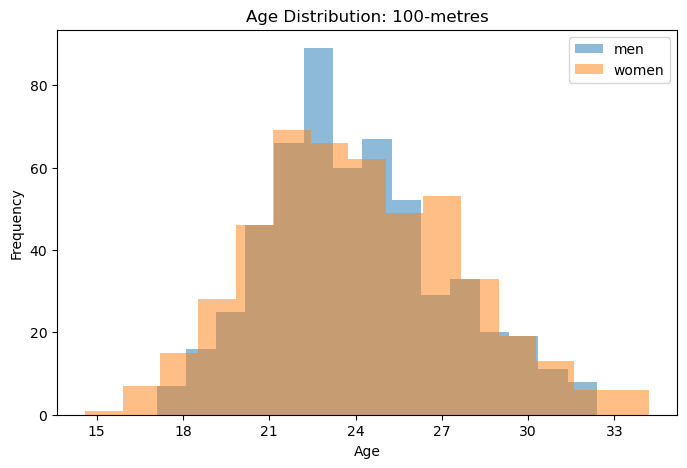

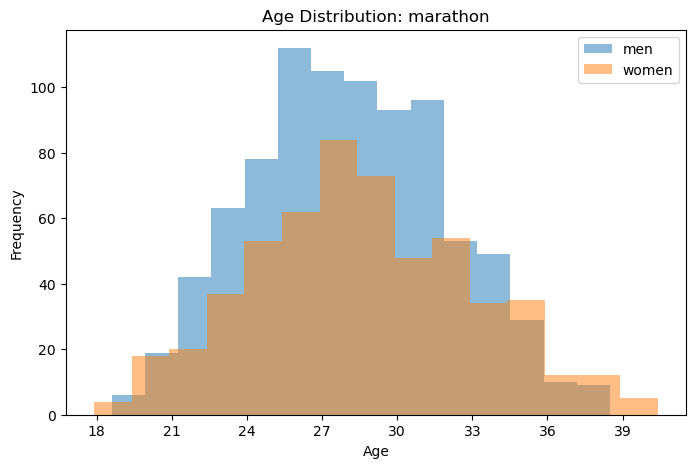

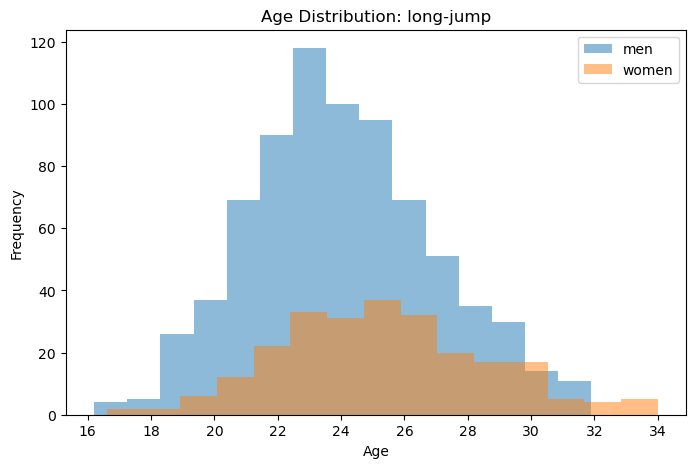

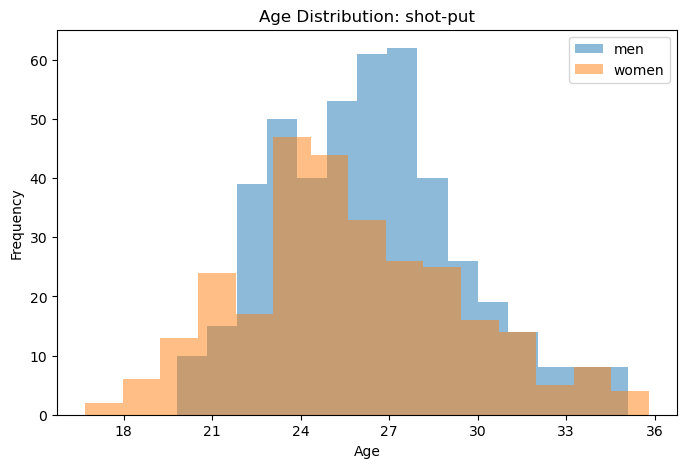

In [182]:
# Plot an age histogram for each event, split by gender
events = [
    '100-metres',
    'marathon',
    'long-jump',
    'shot-put'
]

for event in events:

    event_data = df[df['event_name'] == event]

    plt.figure(figsize=(8, 5))

    for gender in ['men', 'women']:

        gender_data = event_data[
            event_data['gender'] == gender
        ]

        plt.hist(
            gender_data['age'],
            bins=15,
            alpha=0.5,
            label=gender
        )

    plt.xlabel('Age')
    plt.ylabel('Frequency')
    plt.title(f'Age Distribution: {event}')
    plt.legend()

    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

    plt.show()

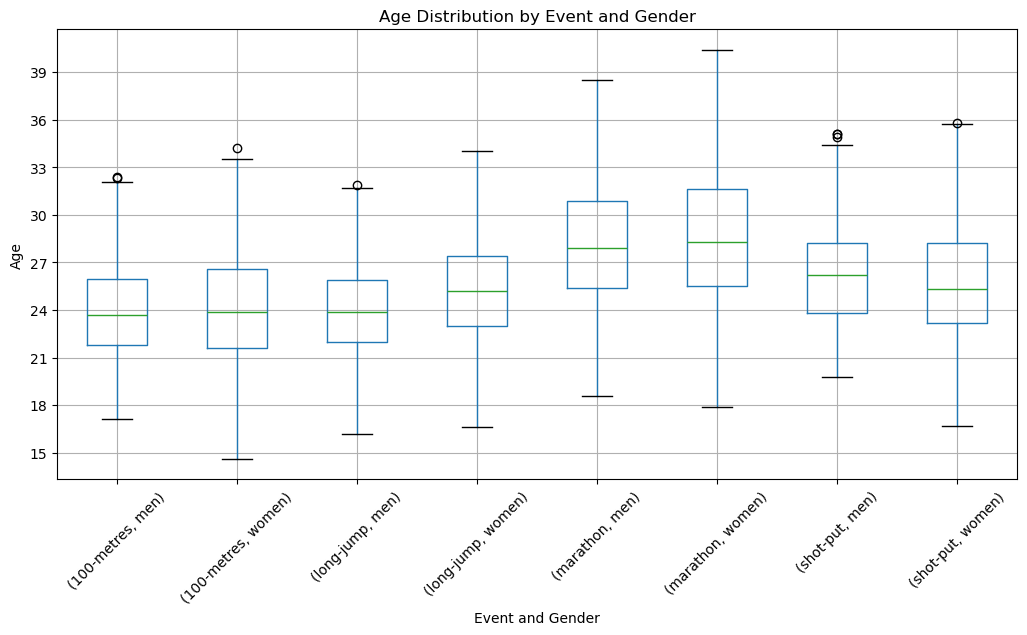

In [183]:
# Use a box plot to compare age distributions across events and genders
df.boxplot(
    column='age',
    by=['event_name', 'gender'],
    figsize=(12, 6)
)

plt.xlabel('Event and Gender')
plt.ylabel('Age')
plt.title('Age Distribution by Event and Gender')
plt.suptitle('')

plt.xticks(rotation=45)

plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))

plt.show()

# Explore Age vs Performance

I next use scatter plots to explore the relationship between age and performance.

Each point represents an athlete's selected personal-best performance. These plots help show whether performance appears to improve or decline with age and how much variation exists between athletes of similar ages.

In [184]:
# Create a separate Men's 100m dataset for the worked example
men_100m = df[
    (df['event_name'] == '100-metres') &
    (df['gender'] == 'men')
].copy()

In [185]:
# Create a separate Women's 100m dataset for comparison
women_100m = df[
    (df['event_name'] == '100-metres') &
    (df['gender'] == 'women')
].copy()

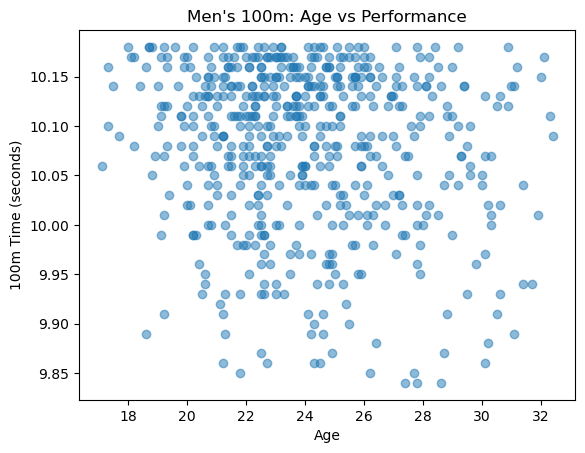

In [186]:
# Plot age against performance for Men's 100m
plt.scatter(
    men_100m['age'],
    men_100m['performance'],
    alpha=0.5
)

plt.xlabel('Age')
plt.ylabel('100m Time (seconds)')
plt.title("Men's 100m: Age vs Performance")

plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

plt.show()

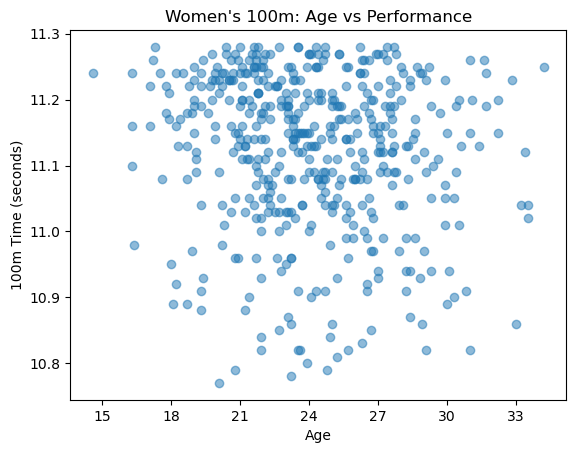

In [187]:
# Plot age against performance for Women's 100m
plt.scatter(
    women_100m['age'],
    women_100m['performance'],
    alpha=0.5
)

plt.xlabel('Age')
plt.ylabel('100m Time (seconds)')
plt.title("Women's 100m: Age vs Performance")

plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

plt.show()

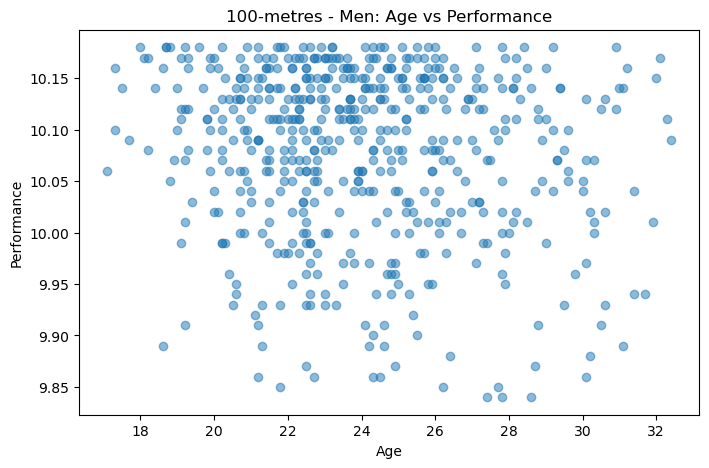

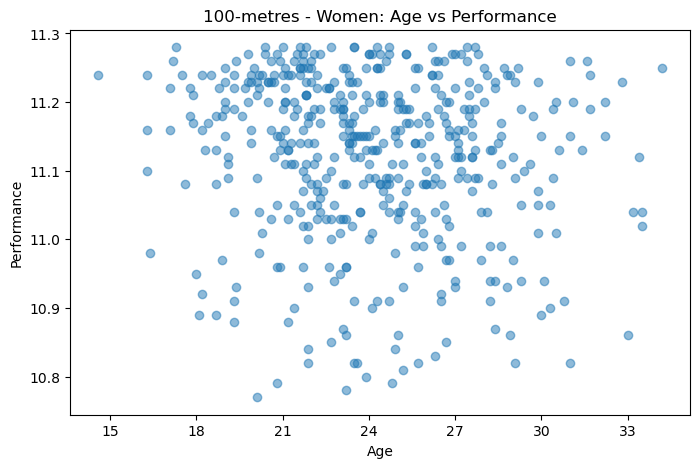

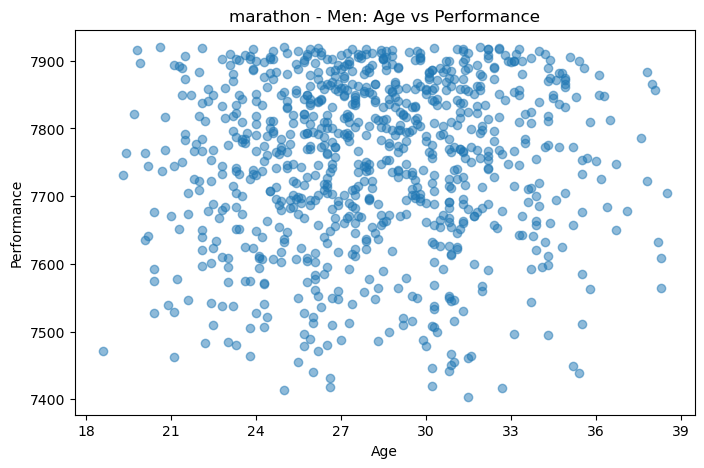

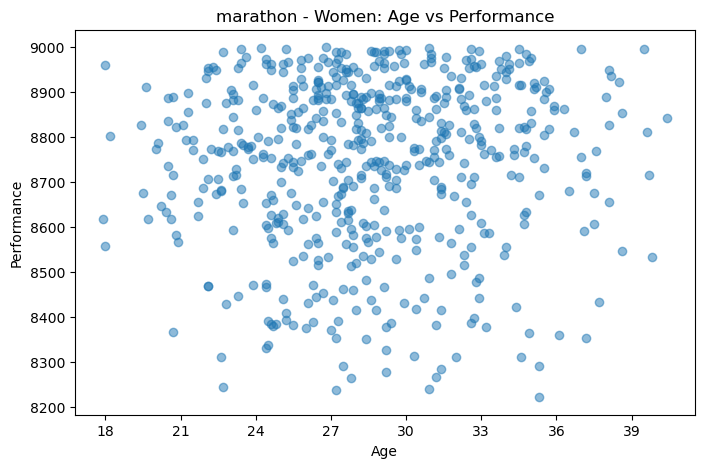

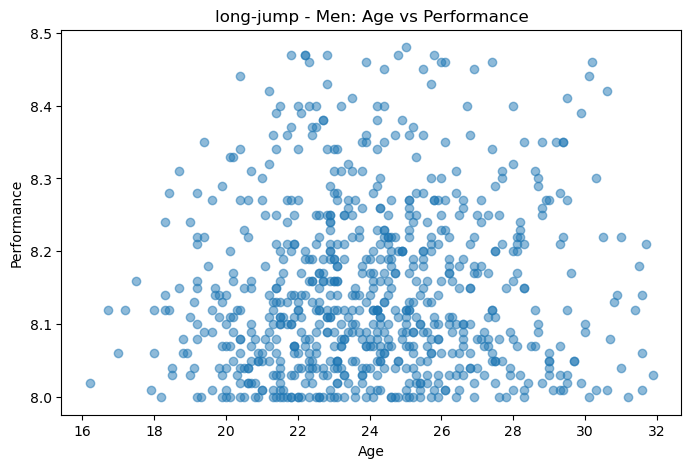

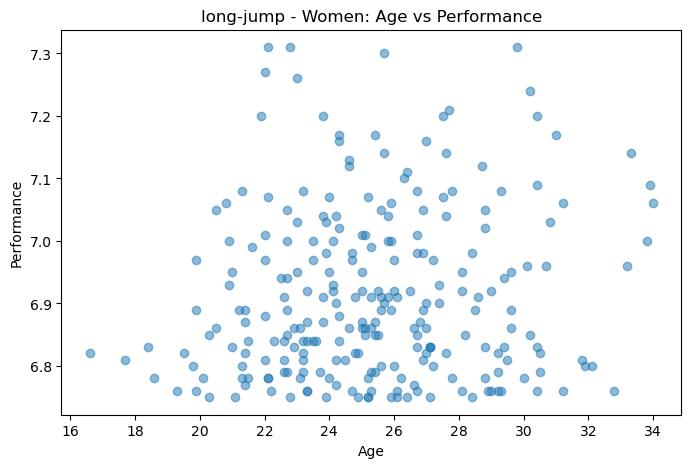

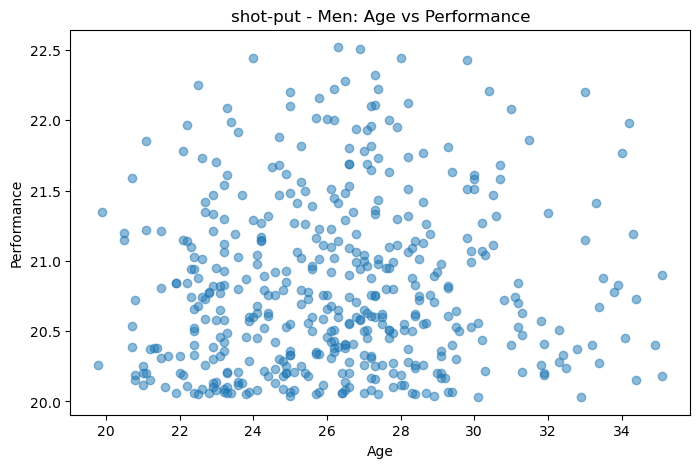

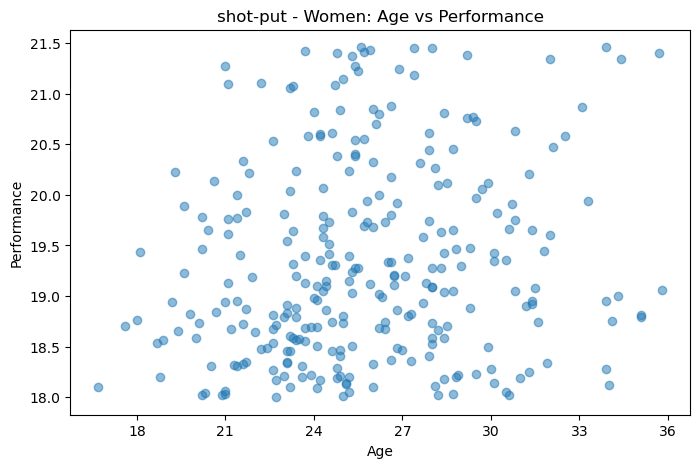

In [188]:
# Plot age against performance for every event and gender
events = [
    '100-metres',
    'marathon',
    'long-jump',
    'shot-put'
]

genders = ['men', 'women']

for event in events:
    for gender in genders:

        subset = df[
            (df['event_name'] == event) &
            (df['gender'] == gender)
        ]

        plt.figure(figsize=(8, 5))

        plt.scatter(
            subset['age'],
            subset['performance'],
            alpha=0.5
        )

        plt.xlabel('Age')
        plt.ylabel('Performance')
        plt.title(
            f'{event} - {gender.capitalize()}: '
            'Age vs Performance'
        )

        plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

        plt.show()

# Correlation Analysis

I calculate the **Pearson correlation coefficient (r)** separately for each event and gender.

The coefficient ranges from **-1 to +1**:

- A value closer to **+1** indicates a stronger positive linear relationship.
- A value closer to **-1** indicates a stronger negative linear relationship.
- A value closer to **0** indicates a weak linear relationship.

The direction needs to be interpreted carefully because lower values are better for the 100m and Marathon, while higher values are better for Long Jump and Shot Put.

Correlation shows association, but it does not show that age causes changes in performance.

In [189]:
# Calculate the correlation between age and performance for each event and gender

correlation_results = []

for event in events:
    for gender in genders:

        subset = df[
            (df['event_name'] == event) &
            (df['gender'] == gender)
        ]

        correlation = subset['age'].corr(subset['performance'])

        correlation_results.append({
            'event_name': event,
            'gender': gender,
            'correlation': correlation
        })

correlations = pd.DataFrame(correlation_results)
correlations['correlation'] = correlations['correlation'].round(3)

correlations


,event_name,gender,correlation
0,100-metres,men,-0.135
1,100-metres,women,-0.118
2,marathon,men,0.062
3,marathon,women,0.052
4,long-jump,men,0.075
5,long-jump,women,0.115
6,shot-put,men,0.067
7,shot-put,women,0.153


# Linear Regression

I start the modelling with linear regression using Men's 100m as a worked example.

Age is used as the independent variable (`X`) and performance is the dependent variable (`y`). The purpose of the linear model is to investigate whether there is a simple straight-line relationship between age and performance.

Linear regression cannot calculate an internal peak age because a straight line does not have a turning point. Peak age is investigated later using polynomial regression.

In [190]:
# Use Men's 100m as the worked example for linear regression
men_100m = df[
    (df['event_name'] == '100-metres') &
    (df['gender'] == 'men')
].copy()

In [191]:
# Set age as the predictor (X) and performance as the target (y)
X = men_100m[['age']]
y = men_100m['performance']

In [192]:
# Split the data into 80% training data and 20% test data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [193]:
# Create the linear regression model and fit it to the training data
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

LinearRegression()

In [194]:
# Use the fitted model to predict the test-set performances
y_pred_linear = linear_model.predict(X_test)

In [195]:
# Calculate MAE, RMSE and R-squared to evaluate the linear model
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

linear_mae = mean_absolute_error(
    y_test,
    y_pred_linear
)

linear_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_linear)
)

linear_r2 = r2_score(
    y_test,
    y_pred_linear
)

print(f"MAE: {linear_mae:.3f}")
print(f"RMSE: {linear_rmse:.3f}")
print(f"R\u00b2: {linear_r2:.3f}")

MAE: 0.067
RMSE: 0.078
R²: 0.026


## Visualise the Fitted Linear Regression Model

The scatter plot shows the observed Men's 100m performances, while the regression line shows the relationship estimated by the linear model.

This makes it easier to see whether there is a clear linear trend and how closely the observations follow the fitted line.

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


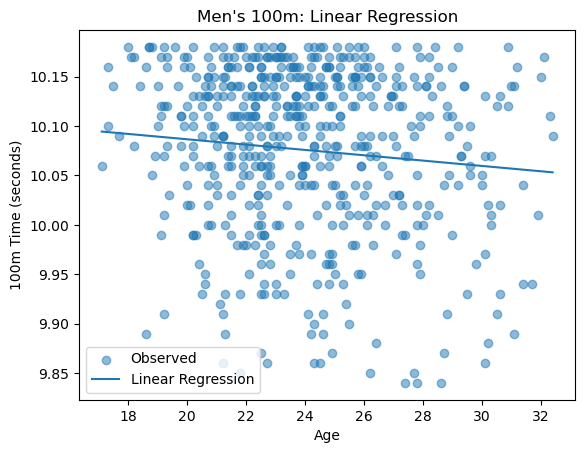

In [196]:
# Create a smooth age range and plot the fitted linear regression line
age_range = np.linspace(
    men_100m['age'].min(),
    men_100m['age'].max(),
    100
).reshape(-1, 1)

linear_predictions = linear_model.predict(age_range)

plt.scatter(
    men_100m['age'],
    men_100m['performance'],
    alpha=0.5,
    label='Observed'
)

plt.plot(
    age_range,
    linear_predictions,
    label='Linear Regression'
)

plt.xlabel('Age')
plt.ylabel('100m Time (seconds)')
plt.title("Men's 100m: Linear Regression")
plt.legend()
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

plt.show()

## Linear Regression Coefficients

The **intercept** is the model's predicted performance when age is zero. This is required mathematically but is not meaningful for this athletics analysis because age zero is outside the observed data.

The **age coefficient** shows the estimated change in predicted performance for a one-year increase in age.

For the 100m and Marathon, a positive coefficient means predicted time increases with age, while a negative coefficient means predicted time decreases. For Long Jump and Shot Put, the interpretation is based on changes in distance.

In [197]:
# Display the fitted intercept and age coefficient
print(f"Intercept: {linear_model.intercept_:.4f}")
print(f"Age coefficient: {linear_model.coef_[0]:.4f}")

Intercept: 10.1405
Age coefficient: -0.0027


# Polynomial Regression

I next apply a **second-degree polynomial regression** to the same Men's 100m data.

The polynomial model includes both `age` and `age-squared`. Adding the squared term allows the fitted relationship to curve, which means the model can potentially identify a turning point.

This is useful for the research question because athletic performance may improve up to a certain age and then decline rather than changing at the same rate throughout an athlete's career.

In [198]:
# Create age and age-squared features for second-degree polynomial regression
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [199]:
# Fit the polynomial regression model using the transformed training data
poly_model = LinearRegression()

poly_model.fit(
    X_train_poly,
    y_train
)

LinearRegression()

In [200]:
# Predict performance for the transformed test data
y_pred_poly = poly_model.predict(
    X_test_poly
)

# Evaluate Polynomial Regression

I evaluate the polynomial model on the test data using the same three measures used for the linear model:

- **MAE** – the average absolute difference between actual and predicted performance.
- **RMSE** – similar to MAE, but gives more weight to larger prediction errors.
- **R-squared** – shows how much of the variation in performance is explained by the model.

These measures help show how well the polynomial model represents performance using age as the predictor.

In [201]:
# Calculate MAE, RMSE and R-squared for the polynomial model
poly_mae = mean_absolute_error(
    y_test,
    y_pred_poly
)

poly_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_poly)
)

poly_r2 = r2_score(
    y_test,
    y_pred_poly
)

print(f"MAE: {poly_mae:.3f}")
print(f"RMSE: {poly_rmse:.3f}")
print(f"R\u00b2: {poly_r2:.3f}")

MAE: 0.067
RMSE: 0.078
R²: 0.011


# Polynomial Turning Point and Peak Age

For a second-degree polynomial, the turning point can be calculated using:

\[
-rac{b_1}{2b_2}
\]

where `b1` is the age coefficient and `b2` is the age-squared coefficient.

However, a turning point is not automatically a valid peak-performance age.

For the **100m and Marathon**, lower times are better, so a valid peak needs to be a **minimum** within the observed age range.

For **Long Jump and Shot Put**, higher distances are better, so a valid peak needs to be a **maximum** within the observed age range.

In [202]:
# Calculate the Men's 100m polynomial turning point and check its age range
b1 = poly_model.coef_[0]
b2 = poly_model.coef_[1]

peak_age = -b1 / (2 * b2)

min_age = men_100m['age'].min()
max_age = men_100m['age'].max()

print(f"Age coefficient (b1): {b1:.6f}")
print(f"Age\u00b2 coefficient (b2): {b2:.6f}")
print(f"Observed age range: {min_age:.2f} to {max_age:.2f} years")

# if b2 > 0 and min_age <= peak_age <= max_age:
#     print("The quadratic has a minimum within the observed age range.")
#     print(f"Estimated peak age: {peak_age:.2f} years")
# elif b2 <= 0:
#     print("The quadratic does not have a minimum, so the turning point should not be interpreted as peak 100m performance.")
# else:
#     print(f"Turning point: {peak_age:.2f} years")
#     print("The turning point lies outside the observed age range, so it should not be interpreted as a reliable peak age.")

Age coefficient (b1): -0.015829
Age² coefficient (b2): 0.000266
Observed age range: 17.10 to 32.40 years


## Interpretation Note

The turning point gives the age where the fitted polynomial curve changes direction.

If it meets the event-specific rules and falls within the observed age range, I report it as the model's estimated **peak age**.

This should not be interpreted as the exact biological age at which an athlete reaches their physical peak. It is an estimate produced by the fitted model and needs to be considered alongside the model's R-squared, MAE and RMSE.

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


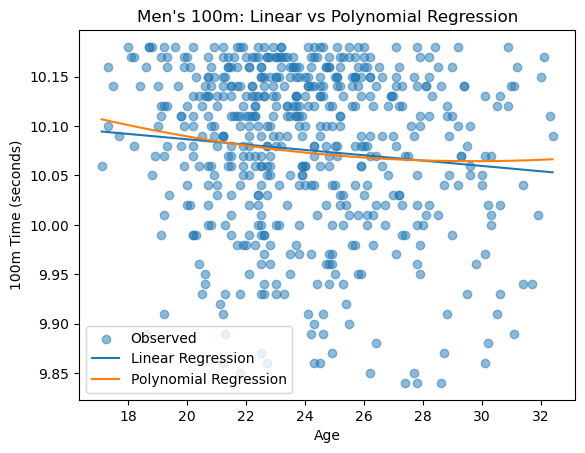

In [203]:
# Plot the Men's 100m polynomial curve and its turning point where appropriate
age_range_poly = poly.transform(age_range)

poly_predictions = poly_model.predict(age_range_poly)

plt.scatter(
    men_100m['age'],
    men_100m['performance'],
    alpha=0.5,
    label='Observed'
)

plt.plot(
    age_range,
    linear_predictions,
    label='Linear Regression'
)

plt.plot(
    age_range,
    poly_predictions,
    label='Polynomial Regression'
)

plt.xlabel('Age')
plt.ylabel('100m Time (seconds)')
plt.title("Men's 100m: Linear vs Polynomial Regression")
plt.legend()

plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

plt.show()

In [204]:
# Print the polynomial coefficients and explain whether the turning point is a valid peak
b1 = poly_model.coef_[0]
b2 = poly_model.coef_[1]

peak_age = -b1 / (2 * b2)

min_age = men_100m['age'].min()
max_age = men_100m['age'].max()

print(f"Age coefficient (b1): {b1:.6f}")
print(f"Age\u00b2 coefficient (b2): {b2:.6f}")
print(f"Observed age range: {min_age:.2f} to {max_age:.2f} years")

if b2 > 0 and min_age <= peak_age <= max_age:
    print("The quadratic has a minimum within the observed age range.")
    print(f"Estimated peak age: {peak_age:.2f} years")

elif b2 <= 0:
    print(
        "The quadratic does not have a minimum, "
        "so the turning point should not be interpreted "
        "as peak 100m performance."
    )

else:
    print(f"Turning point: {peak_age:.2f} years")
    print(
        "The turning point lies outside the observed age range, "
        "so it should not be interpreted as a reliable peak age."
    )

Age coefficient (b1): -0.015829
Age² coefficient (b2): 0.000266
Observed age range: 17.10 to 32.40 years
The quadratic has a minimum within the observed age range.
Estimated peak age: 29.71 years


# Linear Regression for All Events and Genders

After using Men's 100m as a worked example, I repeat the linear regression separately for every event and gender.

This produces eight independent models:

- 100m – Men and Women
- Marathon – Men and Women
- Long Jump – Men and Women
- Shot Put – Men and Women

The models are not based on the Men's 100m model. Each one is fitted using only the observations from its own event and gender.

For each model, I record the age coefficient, MAE, RMSE and R-squared.

In [205]:
# Run linear regression separately for each event and gender

events = ['100-metres', 'marathon', 'long-jump', 'shot-put']
genders = ['men', 'women']

event_labels = {
    '100-metres': '100m',
    'marathon': 'Marathon',
    'long-jump': 'Long Jump',
    'shot-put': 'Shot Put'
}

linear_results = []

for event in events:
    for gender in genders:

        subset = df[
            (df['event_name'] == event) &
            (df['gender'] == gender)
        ].copy()

        X = subset[['age']]
        y = subset['performance']

        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=0.2,
            random_state=42
        )

        linear_model = LinearRegression()
        linear_model.fit(X_train, y_train)

        y_pred = linear_model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        linear_results.append({
            'Event': event_labels[event],
            'Gender': gender.capitalize(),
            'n': len(subset),
            'Intercept': linear_model.intercept_,
            'Age Coefficient': linear_model.coef_[0],
            'MAE': mae,
            'RMSE': rmse,
            'R\u00b2': r2
        })

linear_results_df = pd.DataFrame(linear_results)

columns_to_round = [
    'Intercept',
    'Age Coefficient',
    'MAE',
    'RMSE',
    'R\u00b2'
]

linear_results_df[columns_to_round] = (
    linear_results_df[columns_to_round].round(3)
)

linear_results_df


,Event,Gender,n,Intercept,Age Coefficient,MAE,RMSE,R²
0,100m,Men,548,10.141,-0.003,0.067,0.078,0.026
1,100m,Women,473,11.210,-0.004,0.094,0.118,0.022
2,Marathon,Men,866,7707.508,1.579,97.859,120.347,0.007
3,Marathon,Women,551,8666.114,2.638,140.560,174.338,-0.010
4,Long Jump,Men,754,8.100,0.002,0.102,0.122,0.013
5,Long Jump,Women,245,6.795,0.005,0.095,0.114,-0.050
6,Shot Put,Men,453,20.541,0.010,0.492,0.595,0.009
7,Shot Put,Women,284,18.130,0.046,0.838,1.021,-0.026


## Linear Regression Plots

The plots below show the observed performances and fitted linear regression line for each event and gender.

The **Pearson correlation coefficient (r)** is included in the legend to show the direction and strength of the linear relationship between age and performance.

The plots should be considered alongside the model metrics because a visible trend does not necessarily mean that age explains a large amount of the variation in performance.

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


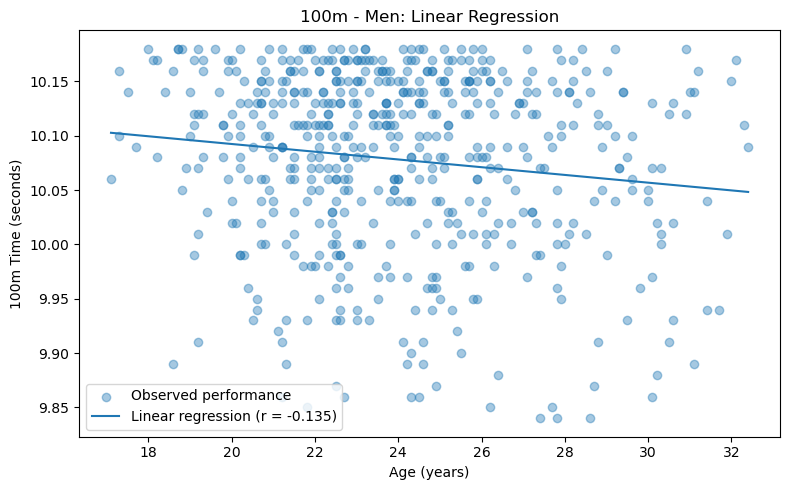

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


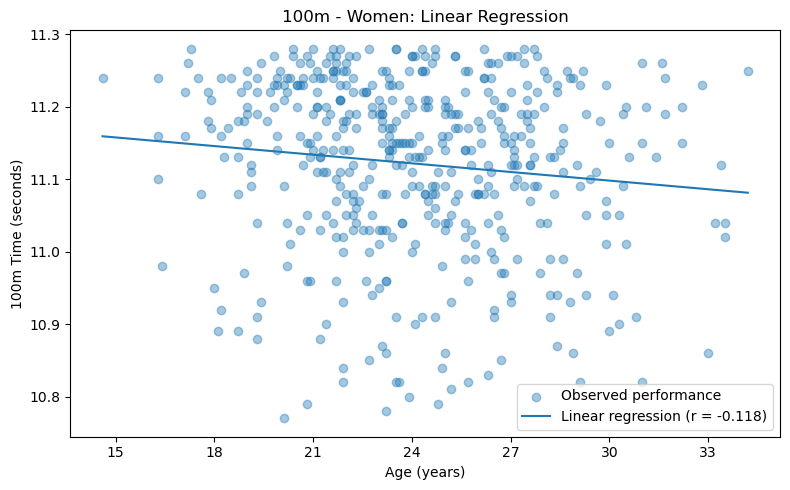

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


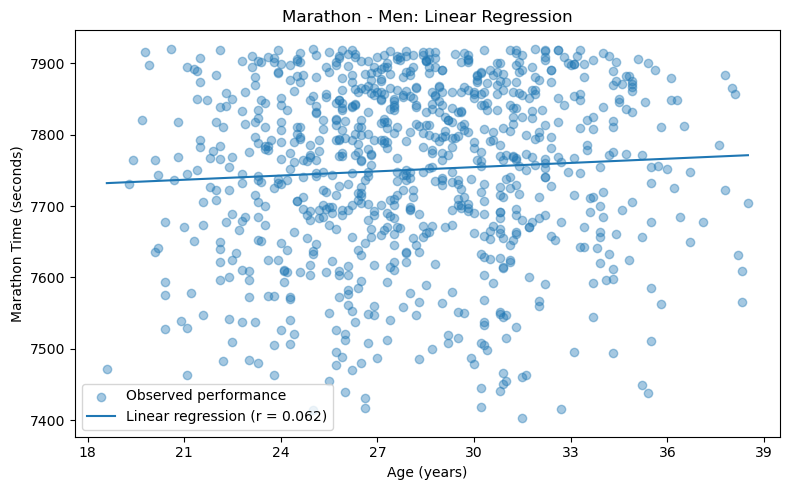

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


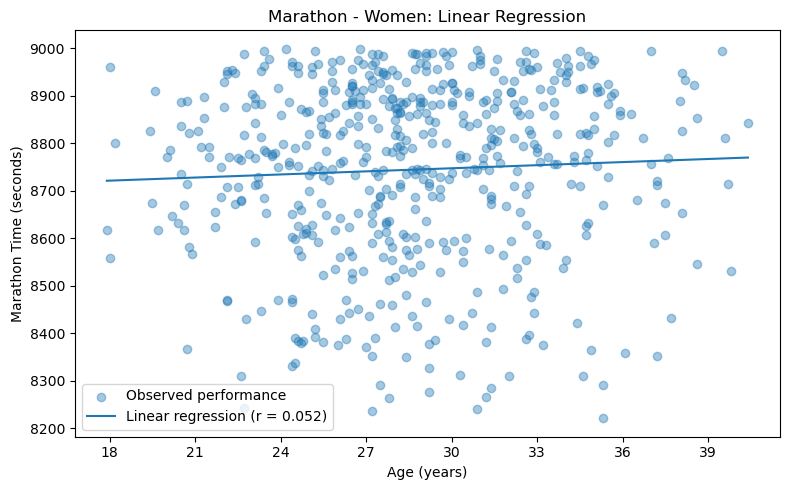

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


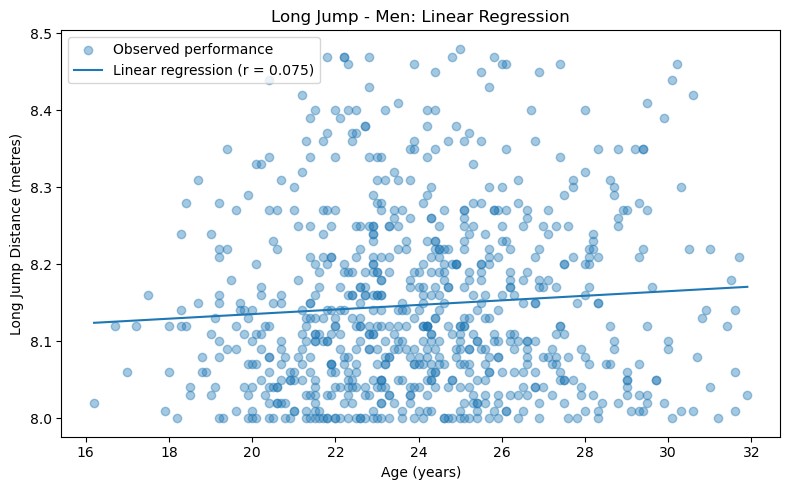

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


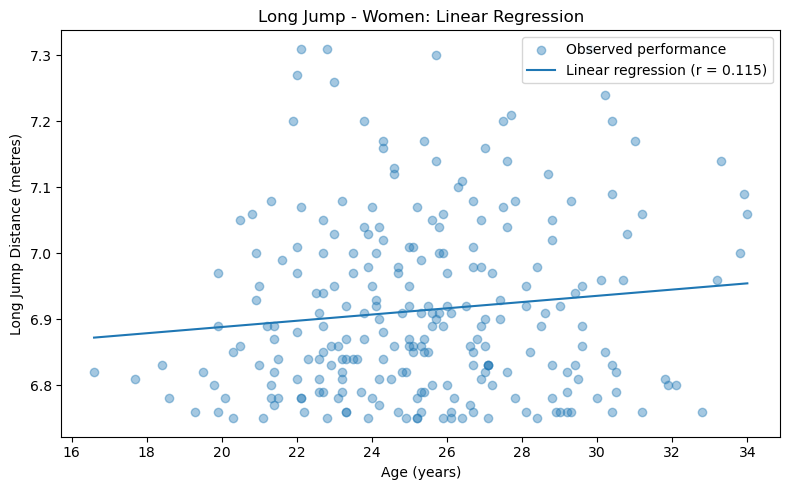

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


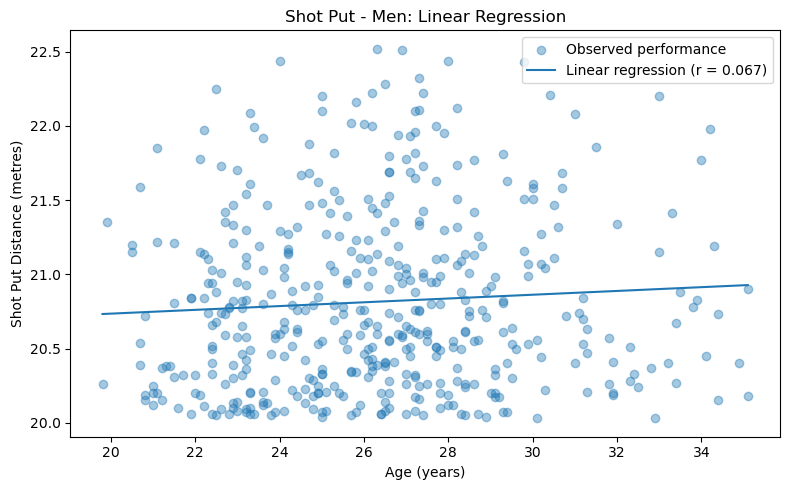

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


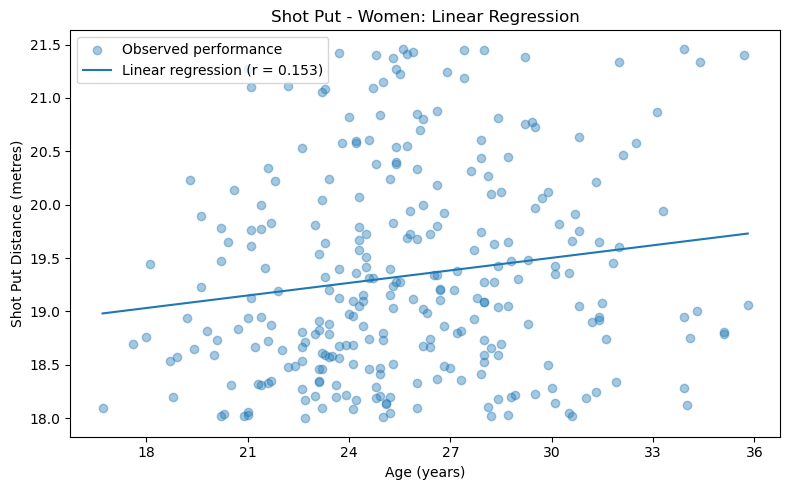

In [206]:
# Plot the linear regression model for each event and gender

for event in events:
    for gender in genders:

        subset = df[
            (df['event_name'] == event) &
            (df['gender'] == gender)
        ].copy()

        X = subset[['age']]
        y = subset['performance']

        # Calculate the Pearson correlation coefficient
        correlation = subset['age'].corr(subset['performance'])

        linear_model = LinearRegression()
        linear_model.fit(X, y)

        age_min = subset['age'].min()
        age_max = subset['age'].max()

        age_range = np.linspace(
            age_min,
            age_max,
            200
        ).reshape(-1, 1)

        predicted_performance = linear_model.predict(age_range)

        plt.figure(figsize=(8, 5))

        plt.scatter(
            subset['age'],
            subset['performance'],
            alpha=0.4,
            label='Observed performance'
        )

        plt.plot(
            age_range,
            predicted_performance,
            label=f'Linear regression (r = {correlation:.3f})'
        )

        plt.xlabel('Age (years)')

        if event == '100-metres':
            plt.ylabel('100m Time (seconds)')
        elif event == 'marathon':
            plt.ylabel('Marathon Time (seconds)')
        elif event == 'long-jump':
            plt.ylabel('Long Jump Distance (metres)')
        elif event == 'shot-put':
            plt.ylabel('Shot Put Distance (metres)')

        plt.title(
            f"{event_labels[event]} - {gender.capitalize()}: Linear Regression"
        )

        # Keep age ticks as whole numbers
        plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

        plt.legend()
        plt.tight_layout()
        plt.show()


# Polynomial Regression for All Events and Genders

I then repeat the second-degree polynomial regression separately for all eight event and gender groups.

For each model, I calculate the polynomial coefficients, MAE, RMSE, R-squared and turning point. The turning point is only reported as a peak age when it represents the best predicted performance for that event and falls within the observed age range.

For timed events, the peak must be a minimum. For distance events, the peak must be a maximum.

In [207]:
# Run polynomial regression separately for each event and gender

polynomial_results = []
polynomial_models = {}

for event in events:
    for gender in genders:

        subset = df[
            (df['event_name'] == event) &
            (df['gender'] == gender)
        ].copy()

        X = subset[['age']]
        y = subset['performance']

        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=0.2,
            random_state=42
        )

        # Create age and age-squared features
        poly = PolynomialFeatures(
            degree=2,
            include_bias=False
        )

        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)

        # Fit the polynomial regression model
        poly_model = LinearRegression()
        poly_model.fit(X_train_poly, y_train)

        y_pred = poly_model.predict(X_test_poly)

        # Model evaluation
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        # Polynomial coefficients
        b1 = poly_model.coef_[0]
        b2 = poly_model.coef_[1]

        min_age = subset['age'].min()
        max_age = subset['age'].max()

        # Calculate the turning point
        if np.isclose(b2, 0):
            turning_point = np.nan
            valid_peak = False

        else:
            turning_point = -b1 / (2 * b2)

            if event in ['100-metres', 'marathon']:
                # Lower times are better, so the curve must have a minimum
                valid_peak = (
                    b2 > 0 and
                    min_age <= turning_point <= max_age
                )

            elif event in ['long-jump', 'shot-put']:
                # Higher distances are better, so the curve must have a maximum
                valid_peak = (
                    b2 < 0 and
                    min_age <= turning_point <= max_age
                )

            else:
                valid_peak = False

        # Only report peak age when the turning point is a valid performance peak
        if valid_peak:
            peak_age = turning_point
        else:
            peak_age = np.nan

        # Save the fitted model so the same model can be used in the graph
        polynomial_models[(event, gender)] = {
            'model': poly_model,
            'poly': poly,
            'turning_point': turning_point,
            'peak_age': peak_age,
            'valid_peak': valid_peak,
            'min_age': min_age,
            'max_age': max_age
        }

        polynomial_results.append({
            'Event': event_labels[event],
            'Gender': gender.capitalize(),
            'n': len(subset),
            'Age Coefficient (b1)': b1,
            'Age\u00b2 Coefficient (b2)': b2,
            'MAE': mae,
            'RMSE': rmse,
            'R\u00b2': r2,
            'Polynomial Turning Point': turning_point,
            'Polynomial Peak Age': peak_age,
            'Valid Polynomial Peak?': 'Yes' if valid_peak else 'No'
        })

polynomial_results_df = pd.DataFrame(polynomial_results)

# Remove these columns from the final displayed table.
# The peak calculations are still kept in polynomial_models for the graphs.
polynomial_results_df = polynomial_results_df.drop(
    columns=['Polynomial Peak Age', 'Valid Polynomial Peak?']
)

# Show extra decimal places for the polynomial coefficients
polynomial_results_df['Age Coefficient (b1)'] = (
    polynomial_results_df['Age Coefficient (b1)'].round(6)
)

polynomial_results_df['Age\u00b2 Coefficient (b2)'] = (
    polynomial_results_df['Age\u00b2 Coefficient (b2)'].round(6)
)

# Round the remaining model results to three decimal places
columns_to_round = [
    'MAE',
    'RMSE',
    'R\u00b2',
    'Polynomial Turning Point'
]

polynomial_results_df[columns_to_round] = (
    polynomial_results_df[columns_to_round].round(3)
)

polynomial_results_df


,Event,Gender,n,Age Coefficient (b1),Age² Coefficient (b2),MAE,RMSE,R²,Polynomial Turning Point
0,100m,Men,548,-0.015829,0.000266,0.067,0.078,0.011,29.710
1,100m,Women,473,-0.025637,0.000450,0.095,0.119,0.008,28.498
2,Marathon,Men,866,23.137390,-0.378470,97.227,119.916,0.014,30.567
3,Marathon,Women,551,12.326290,-0.167251,141.138,174.950,-0.017,36.850
4,Long Jump,Men,754,0.045484,-0.000888,0.102,0.122,0.013,25.624
5,Long Jump,Women,245,0.034226,-0.000567,0.096,0.116,-0.072,30.163
6,Shot Put,Men,453,0.219117,-0.003858,0.489,0.591,0.022,28.396
7,Shot Put,Women,284,0.375308,-0.006254,0.846,1.028,-0.041,30.006


## Polynomial Regression Plots

Each graph uses the same polynomial model that was fitted on the training data for that event and gender.

This keeps the graph consistent with the coefficients, test-set metrics, turning point and peak-age result shown in the polynomial results table.

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


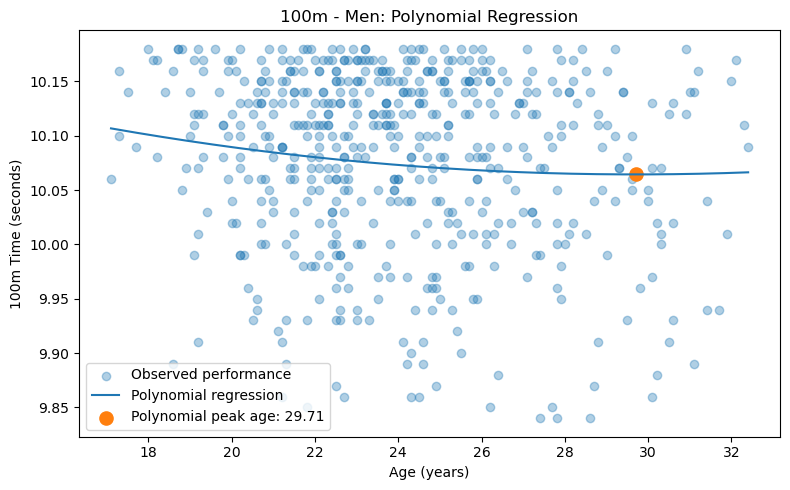

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


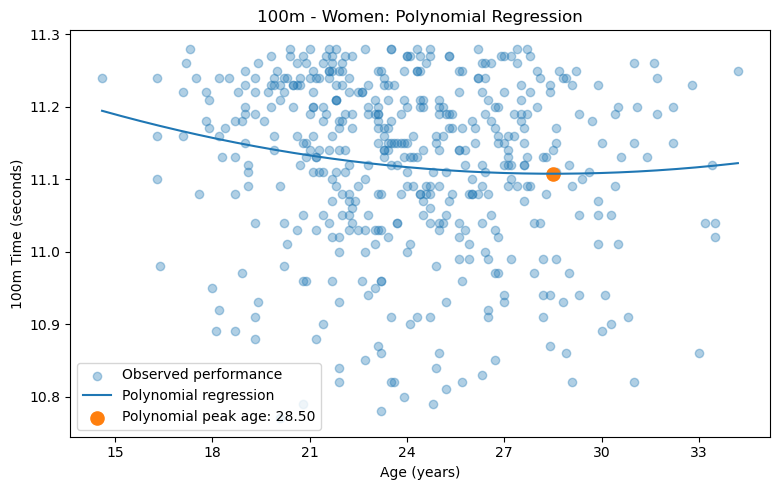

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


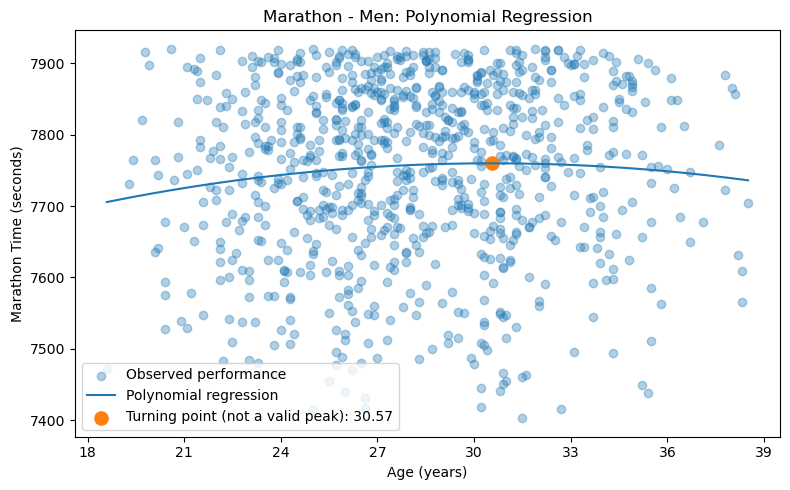

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


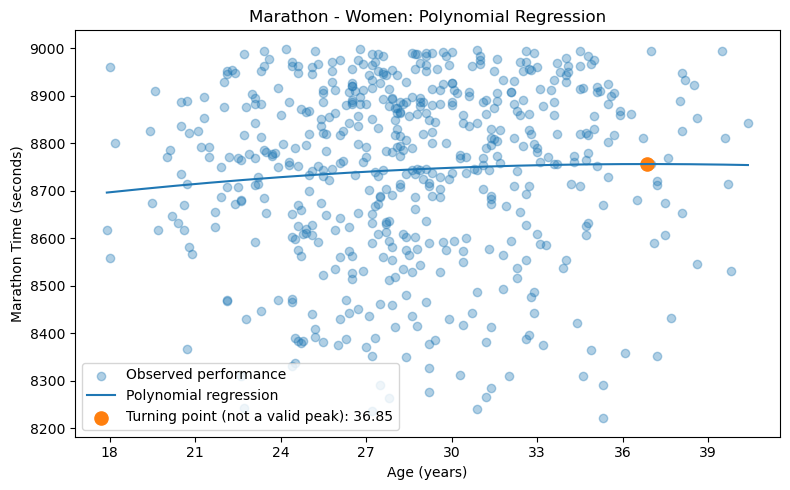

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


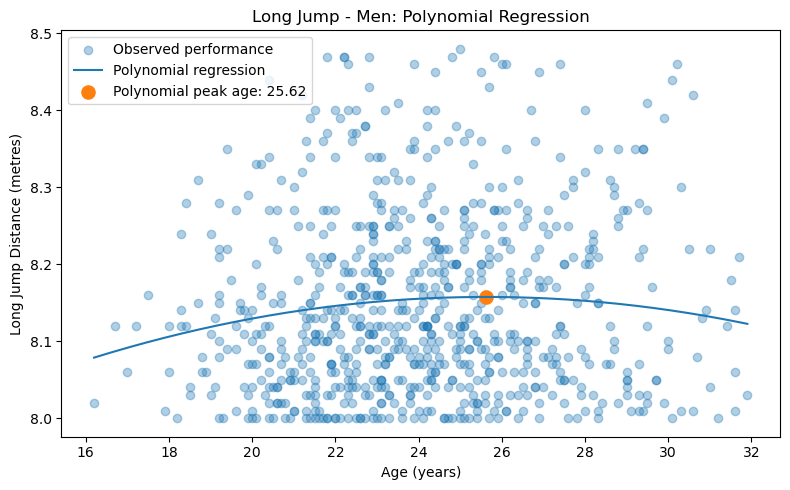

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


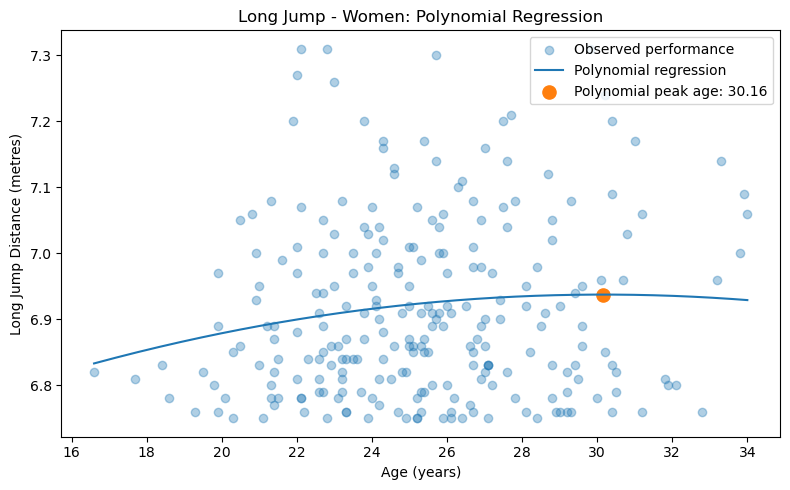

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


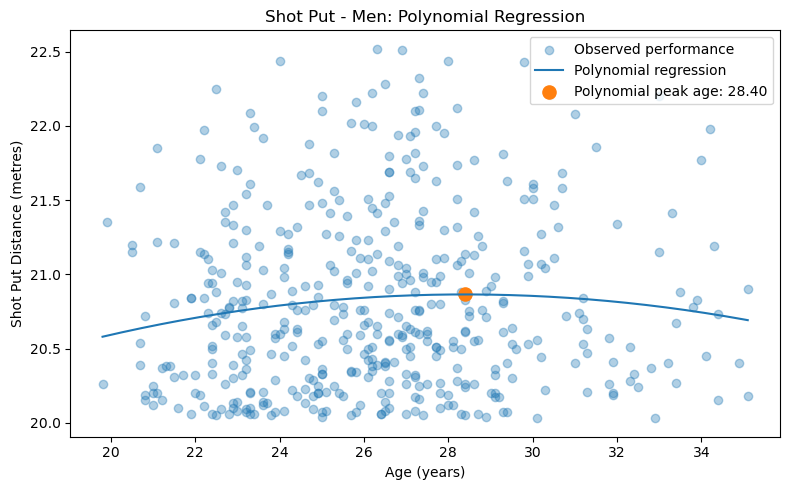

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


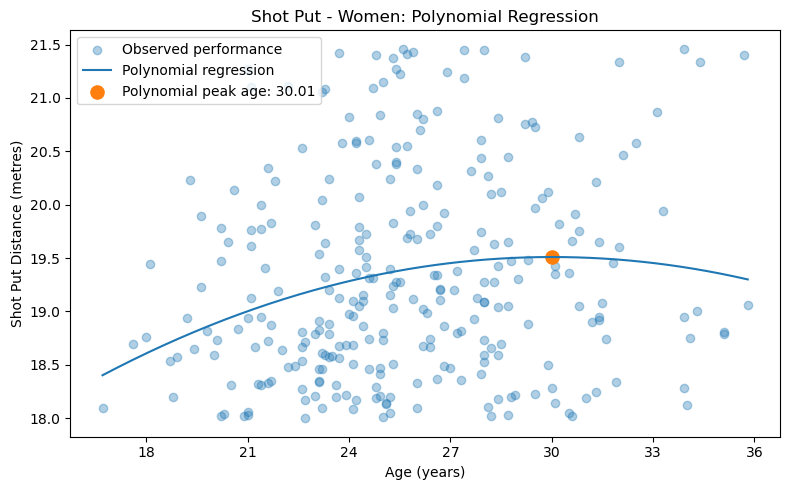

In [208]:
# Plot the polynomial regression model for each event and gender

for event in events:
    for gender in genders:

        subset = df[
            (df['event_name'] == event) &
            (df['gender'] == gender)
        ].copy()

        # Get the same fitted model used in the results table
        stored_model = polynomial_models[(event, gender)]

        poly_model = stored_model['model']
        poly = stored_model['poly']
        turning_point = stored_model['turning_point']
        valid_peak = stored_model['valid_peak']
        min_age = stored_model['min_age']
        max_age = stored_model['max_age']

        # Create a smooth age range for the fitted curve
        age_range = np.linspace(
            min_age,
            max_age,
            300
        ).reshape(-1, 1)

        age_range_poly = poly.transform(age_range)
        predicted_performance = poly_model.predict(age_range_poly)

        plt.figure(figsize=(8, 5))

        plt.scatter(
            subset['age'],
            subset['performance'],
            alpha=0.35,
            label='Observed performance'
        )

        plt.plot(
            age_range,
            predicted_performance,
            label='Polynomial regression'
        )

        # Add the turning point if it is inside the observed age range
        turning_point_in_range = (
            not np.isnan(turning_point) and
            min_age <= turning_point <= max_age
        )

        if turning_point_in_range:

            turning_point_poly = poly.transform([[turning_point]])
            turning_performance = poly_model.predict(
                turning_point_poly
            )[0]

            if valid_peak:
                label_text = (
                    f'Polynomial peak age: {turning_point:.2f}'
                )
            else:
                label_text = (
                    f'Turning point (not a valid peak): {turning_point:.2f}'
                )

            plt.scatter(
                turning_point,
                turning_performance,
                s=90,
                label=label_text
            )

        plt.xlabel('Age (years)')

        if event == '100-metres':
            plt.ylabel('100m Time (seconds)')
        elif event == 'marathon':
            plt.ylabel('Marathon Time (seconds)')
        elif event == 'long-jump':
            plt.ylabel('Long Jump Distance (metres)')
        elif event == 'shot-put':
            plt.ylabel('Shot Put Distance (metres)')

        plt.title(
            f"{event_labels[event]} - {gender.capitalize()}: Polynomial Regression"
        )

        plt.legend()
        plt.tight_layout()

        # Keep age ticks as whole numbers
        plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

        plt.show()
